# YOLOv11-Seg Training — Global Camera (Project 1)

**Model:** YOLOv11-Large Segmentation (`yolo11l-seg.pt`) — 27.7M parameters  
**Task:** Instance segmentation of 18 HDD component classes  
**Camera:** Orbbec overhead camera — 1088×1088 px  
**Why segmentation:** Labels are already in YOLO polygon format — no conversion needed.

### Pipeline
1. Download dataset from Roboflow (polygon labels)
2. Split into 80/10/10 train/val/test — keep labels as-is
3. Train YOLOv11l-seg at 1088×1088
4. Plot training curves
5. Preview inference with segmentation masks

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1: Download dataset and split into train/val/test
#
# The Roboflow export has two label formats mixed in the same folder:
#   • Polygon lines  — class x1 y1 x2 y2 ... xN yN  (>= 7 tokens, even coords)
#   • BBox lines     — class cx cy w h                (exactly 5 tokens)
#
# YOLO segmentation silently drops pure bbox lines. We convert each bbox to a
# 4-vertex rectangular polygon so no annotation is lost.
# ─────────────────────────────────────────────────────────────────────────────
from roboflow import Roboflow
import os
import random
import shutil
import yaml

rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("electronic_device_global")
version = project.version(1)
dataset = version.download("yolov8")

DATA_PATH  = dataset.location        # e.g. Electronic_Device_Global-1
OUTPUT_DIR = "dataset_yolo11_seg_1080"


def _convert_label_line(raw: str):
    """Return a YOLO-seg polygon line, converting bbox→rect-polygon if needed.

    Returns None if the line is empty or malformed (will be skipped).
    """
    parts = raw.strip().split()
    if len(parts) < 5:
        return None                      # malformed — skip
    cls    = parts[0]
    coords = [float(p) for p in parts[1:]]

    if len(coords) == 4:
        # BBox format: cx cy w h  →  4-vertex rectangle polygon (clockwise)
        cx, cy, w, h = coords
        x1, y1 = cx - w / 2, cy - h / 2   # top-left
        x2, y2 = cx + w / 2, cy - h / 2   # top-right
        x3, y3 = cx + w / 2, cy + h / 2   # bottom-right
        x4, y4 = cx - w / 2, cy + h / 2   # bottom-left
        pts = [max(0.0, min(1.0, v)) for v in [x1, y1, x2, y2, x3, y3, x4, y4]]
        return cls + " " + " ".join(f"{v:.6f}" for v in pts)

    if len(coords) % 2 != 0 or len(coords) < 6:
        return None                      # odd-length or degenerate polygon — skip

    # Already a polygon — normalise float formatting and pass through
    return cls + " " + " ".join(f"{v:.6f}" for v in coords)


# Create split directory structure
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "labels"), exist_ok=True)

# All augmented images live in train/ — split 80/10/10
images_dir = os.path.join(DATA_PATH, "train", "images")
labels_dir = os.path.join(DATA_PATH, "train", "labels")

images = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".jpg")])
random.seed(42)
random.shuffle(images)

train_idx = int(len(images) * 0.80)
val_idx   = int(len(images) * 0.90)
splits = {
    "train": images[:train_idx],
    "valid": images[train_idx:val_idx],
    "test":  images[val_idx:],
}

converted_bbox = 0
skipped_bad    = 0

for split_name, img_list in splits.items():
    for img_name in img_list:
        # Copy image
        shutil.copy(
            os.path.join(images_dir, img_name),
            os.path.join(OUTPUT_DIR, split_name, "images", img_name),
        )
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_src  = os.path.join(labels_dir, label_name)
        label_dst  = os.path.join(OUTPUT_DIR, split_name, "labels", label_name)

        if not os.path.exists(label_src):
            open(label_dst, "w").close()   # empty label for unannotated image
            continue

        out_lines = []
        with open(label_src) as fh:
            for raw in fh:
                if not raw.strip():
                    continue
                parts = raw.strip().split()
                converted = _convert_label_line(raw)
                if converted is None:
                    skipped_bad += 1
                else:
                    if len(parts) == 5:    # was a bbox line → now rect-polygon
                        converted_bbox += 1
                    out_lines.append(converted)

        with open(label_dst, "w") as fh:
            fh.write("\n".join(out_lines) + ("\n" if out_lines else ""))

# Write data.yaml in YOLO format (absolute path for portability)
with open(os.path.join(DATA_PATH, "data.yaml"), "r") as fh:
    source_yaml = yaml.safe_load(fh)

data_yaml = {
    "path": os.path.abspath(OUTPUT_DIR),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    source_yaml["nc"],
    "names": source_yaml["names"],
}

yaml_path = os.path.join(OUTPUT_DIR, "data.yaml")
with open(yaml_path, "w") as fh:
    yaml.dump(data_yaml, fh, default_flow_style=False, sort_keys=False)

print(f"✅ Dataset split complete ({OUTPUT_DIR}/)")
print(f"   train: {len(splits['train'])}  val: {len(splits['valid'])}  test: {len(splits['test'])}")
print(f"   Classes ({data_yaml['nc']}): {data_yaml['names']}")
print(f"   BBox lines converted to rect-polygon : {converted_bbox}")
print(f"   Malformed lines skipped              : {skipped_bad}")
print(f"   data.yaml → {os.path.abspath(yaml_path)}")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset split complete (dataset_yolo11_seg_1080/)
   train: 2240  val: 280  test: 280
   Classes (18): ['battery', 'battery_screw', 'case', 'core_holder', 'core_holder_screw', 'hdd_holder', 'hdd_holder_screw', 'heat_sink', 'heat_sink_screw', 'hole', 'lid', 'lid_screw', 'pcb', 'pcb_holder', 'pcb_holder_screw', 'pcb_screw', 'ssd_holder', 'ssd_holder_Screw']
   BBox lines converted to rect-polygon : 2648
   Malformed lines skipped              : 0
   data.yaml → /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/data.yaml


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2: Validate dataset — verify all labels are clean YOLO-seg polygons
# After Cell 1 every line should be: class x1 y1 x2 y2 ... xN yN (>= 3 verts)
# YOLO segmentation minimum: class + 3 vertices = 7 tokens
# ─────────────────────────────────────────────────────────────────────────────
import glob
import numpy as np

label_files  = glob.glob(os.path.join(OUTPUT_DIR, "train", "labels", "*.txt"))
issues       = []
class_counts = {}
vertex_counts = []

for lf in label_files:
    with open(lf) as fh:
        for lineno, line in enumerate(fh, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # Minimum valid seg line: class + 3 vertices = 7 tokens
            if len(parts) < 7:
                issues.append(f"{os.path.basename(lf)}:{lineno} — too few tokens ({len(parts)})")
                continue
            cls = int(parts[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1
            coords = list(map(float, parts[1:]))
            if len(coords) % 2 != 0:
                issues.append(f"{os.path.basename(lf)}:{lineno} — odd coord count ({len(coords)})")
            else:
                vertex_counts.append(len(coords) // 2)
                out_of_range = [v for v in coords if not (0.0 <= v <= 1.0)]
                if out_of_range:
                    issues.append(
                        f"{os.path.basename(lf)}:{lineno} — coords out of [0,1]: {out_of_range[:4]}"
                    )

total_anns = sum(class_counts.values())
print(f"Label files checked : {len(label_files)}")
print(f"Total annotations   : {total_anns}")
if vertex_counts:
    print(f"Avg polygon vertices: {np.mean(vertex_counts):.1f}  "
          f"(min={min(vertex_counts)}, max={max(vertex_counts)})")
print(f"Issues found        : {len(issues)}")

if issues:
    print("\n⚠️  First 10 issues:")
    for i in issues[:10]:
        print(f"  {i}")
else:
    print("✅ All labels are valid YOLO segmentation polygons")

# Per-class breakdown
with open(yaml_path) as fh:
    cfg = yaml.safe_load(fh)
class_names = cfg["names"]

print("\nClass distribution in train split:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
    pct  = 100.0 * count / max(total_anns, 1)
    print(f"  [{cls_id:2d}] {name:<20}: {count:>5}  ({pct:.1f}%)")

Label files checked : 2240
Total annotations   : 55144
Avg polygon vertices: 33.3  (min=3, max=451)
Issues found        : 0
✅ All labels are valid YOLO segmentation polygons

Class distribution in train split:
  [ 0] battery             :  1879  (3.4%)
  [ 1] battery_screw       :  2205  (4.0%)
  [ 2] case                :  2001  (3.6%)
  [ 3] core_holder         :  1786  (3.2%)
  [ 4] core_holder_screw   :  3420  (6.2%)
  [ 5] hdd_holder          :  1887  (3.4%)
  [ 6] hdd_holder_screw    :  2928  (5.3%)
  [ 7] heat_sink           :  3656  (6.6%)
  [ 8] heat_sink_screw     :  5401  (9.8%)
  [ 9] hole                :  3558  (6.5%)
  [10] lid                 :  2035  (3.7%)
  [11] lid_screw           :  4931  (8.9%)
  [12] pcb                 :  5834  (10.6%)
  [13] pcb_holder          :  1912  (3.5%)
  [14] pcb_holder_screw    :  4301  (7.8%)
  [15] pcb_screw           :  5618  (10.2%)
  [16] ssd_holder          :   988  (1.8%)
  [17] ssd_holder_Screw    :   804  (1.5%)


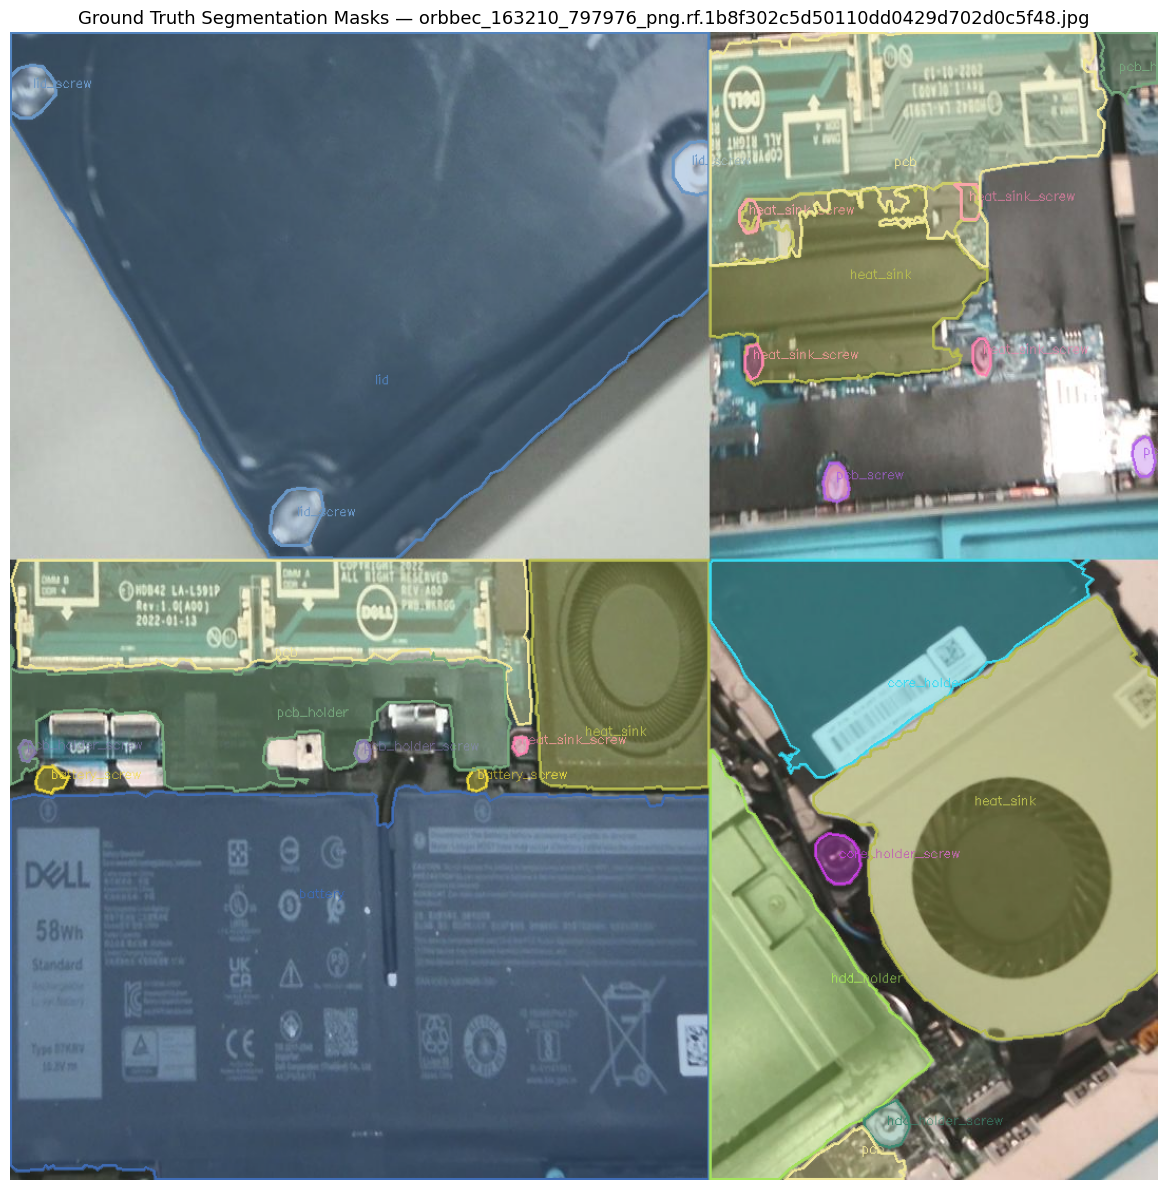

Image: dataset_yolo11_seg_1080/train/images/orbbec_163210_797976_png.rf.1b8f302c5d50110dd0429d702d0c5f48.jpg  |  Size: 1088×1088


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3: Preview ground-truth segmentation masks
# ─────────────────────────────────────────────────────────────────────────────
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

with open(yaml_path) as fh:
    cfg = yaml.safe_load(fh)
class_names = cfg["names"]

# Pick a random training image
train_imgs = sorted(glob.glob(os.path.join(OUTPUT_DIR, "train", "images", "*.jpg")))
img_path   = random.choice(train_imgs)
lbl_path   = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")

img = cv2.imread(img_path)
H, W = img.shape[:2]
overlay = img.copy()

# Colour palette — one per class
rng = np.random.default_rng(0)
palette = (rng.random((len(class_names), 3)) * 200 + 55).astype(int).tolist()

with open(lbl_path) as fh:
    for line in fh:
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls  = int(parts[0])
        coords = list(map(float, parts[1:]))
        pts = np.array([[coords[i]*W, coords[i+1]*H] for i in range(0, len(coords), 2)],
                       dtype=np.int32).reshape((-1, 1, 2))
        color = tuple(palette[cls % len(palette)])
        cv2.fillPoly(overlay, [pts], color)
        cv2.polylines(img, [pts], True, color, 2)
        # Label at centroid
        cx, cy = int(pts[:, 0, 0].mean()), int(pts[:, 0, 1].mean())
        cv2.putText(img, class_names[cls] if cls < len(class_names) else str(cls),
                    (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

vis = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Ground Truth Segmentation Masks — {os.path.basename(img_path)}", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Image: {img_path}  |  Size: {W}×{H}")

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4: Train YOLOv11l-seg
#
# Hardware target: RTX 4070 Laptop GPU (8 GB VRAM)
#   imgsz=1088      → divisible by 32 (34×32=1088)
#   batch=8         → safe for 8 GB with 27M-param model
#   workers=8       → saturate CPU-side data loading
#   epochs=200      → model was still improving at epoch 100 (mAP50-95 climbing)
#   patience=30     → wider window since gains are small but consistent after ep75
#   copy_paste=0.3  → copies small objects onto new backgrounds; improves small-
#                     object recall (screws, holes — 65% of dataset is small objs)
#
# Note: YOLO writes output to <project>/<name>/.
#   project="runs"  name="yolo11l_seg_1088"  →  runs/yolo11l_seg_1088/
#   Set exist_ok=True so re-running resumes into the same directory.
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

RUN_NAME = "yolo11l_seg_1088"
RUN_DIR  = os.path.join("runs", RUN_NAME)          # actual output directory

model = YOLO("yolo11l-seg.pt")   # COCO-pretrained Large segmentation weights

results = model.train(
    data      = os.path.abspath(yaml_path),
    epochs    = 200,             # extended: was 100, model hadn't fully converged
    imgsz     = 1088,
    batch     = 8,
    workers   = 8,
    patience  = 30,              # extended: was 20, gains are slow but real after ep75
    optimizer = "AdamW",
    lr0       = 0.001,
    lrf       = 0.01,
    momentum  = 0.937,
    weight_decay = 0.0005,
    # Augmentation
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    degrees   = 10.0,
    translate = 0.1,
    scale     = 0.5,
    fliplr    = 0.5,
    mosaic    = 1.0,
    close_mosaic = 10,
    copy_paste= 0.3,             # added: boosts small-object recall (screws/holes)
    # Output location
    project   = "runs",
    name      = RUN_NAME,
    exist_ok  = True,            # resume into same directory if re-running
    save      = True,
    plots     = True,
    verbose   = True,
)

print(f"\n✅ Training complete. Results saved to: {RUN_DIR}/")
print(f"   Best weights: {RUN_DIR}/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1088, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, l

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2773.4±1682.3 MB/s, size: 100.3 KB)
val: Scanning /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/valid/labels... 280 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 280/280 961.8it/s 0.3ss
val: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/valid/images/orbbec_160047_125411_png.rf.a447475753bf7c493c19e09912aeb1a8.jpg: 2 duplicate labels removed
val: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/valid/images/orbbec_160602_071458_png.rf.27824dfc2b5532eeed0a9d54bad38cd9.jpg: 1 duplicate labels removed
val: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/valid/images/orbbec_161155_470913_png.rf.c0750473

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5: Parse YOLO CSV results and report best metrics
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

csv_path = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/results.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()   # remove leading/trailing spaces

    print("Available metric columns:")
    print([c for c in df.columns])

    # YOLO segmentation CSV column names:
    #   metrics/mAP50(M)     — segmentation mAP@0.5
    #   metrics/mAP50-95(M)  — segmentation mAP@0.5:0.95
    #   metrics/mAP50(B)     — box mAP@0.5  (also logged)
    seg_map50    = "metrics/mAP50(M)"
    seg_map5095  = "metrics/mAP50-95(M)"
    box_map50    = "metrics/mAP50(B)"

    for col in [seg_map50, seg_map5095, box_map50]:
        if col in df.columns:
            best_val = df[col].max()
            best_ep  = df[col].idxmax() + 1
            print(f"\n🏆 Best {col}: {best_val:.4f}  (epoch {best_ep})")
else:
    print(f"❌ {csv_path} not found — run training cell first.")

Available metric columns:
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

🏆 Best metrics/mAP50(M): 0.9556  (epoch 183)

🏆 Best metrics/mAP50-95(M): 0.7812  (epoch 183)

🏆 Best metrics/mAP50(B): 0.9575  (epoch 180)


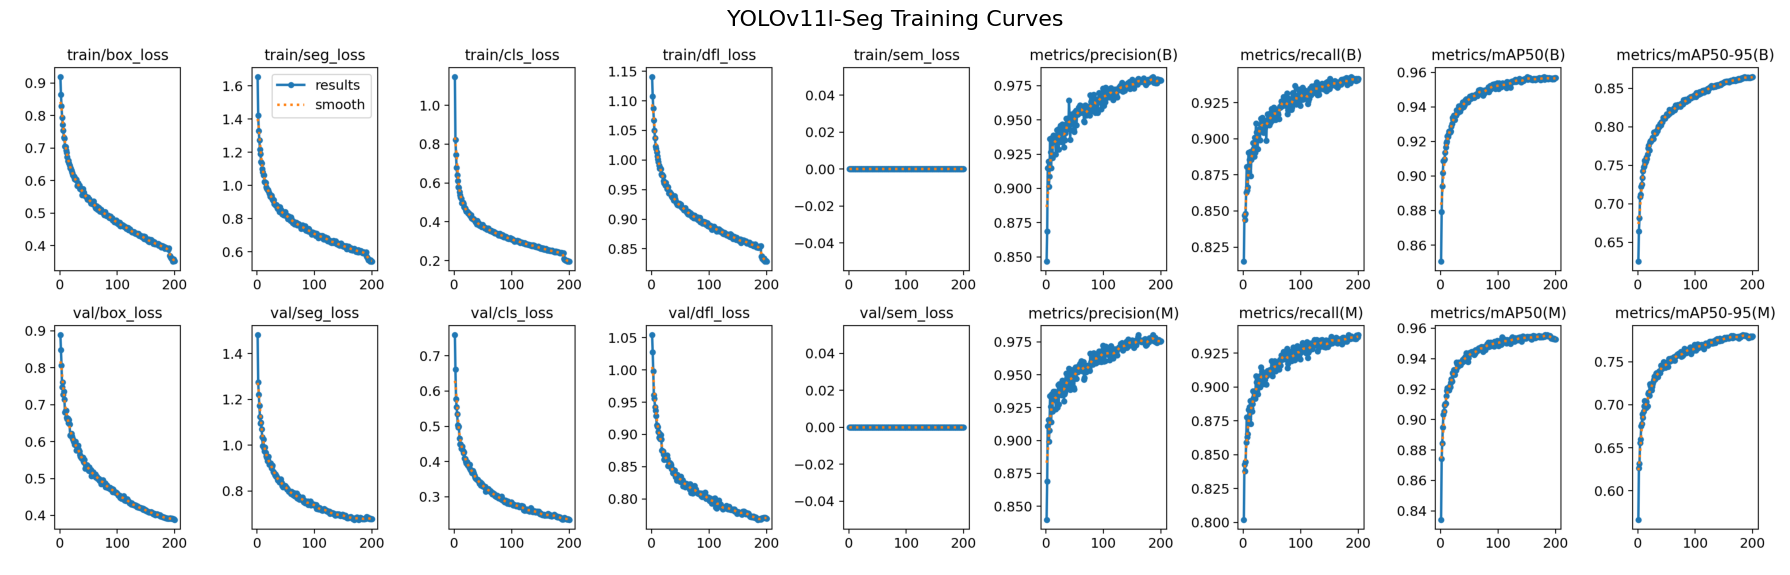

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6: Show YOLO auto-generated training curves image
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.image as mpimg

plot_path = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/results.png"

if os.path.exists(plot_path):
    plt.figure(figsize=(18, 10))
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLOv11l-Seg Training Curves", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ {plot_path} not found — training plots are generated automatically.")

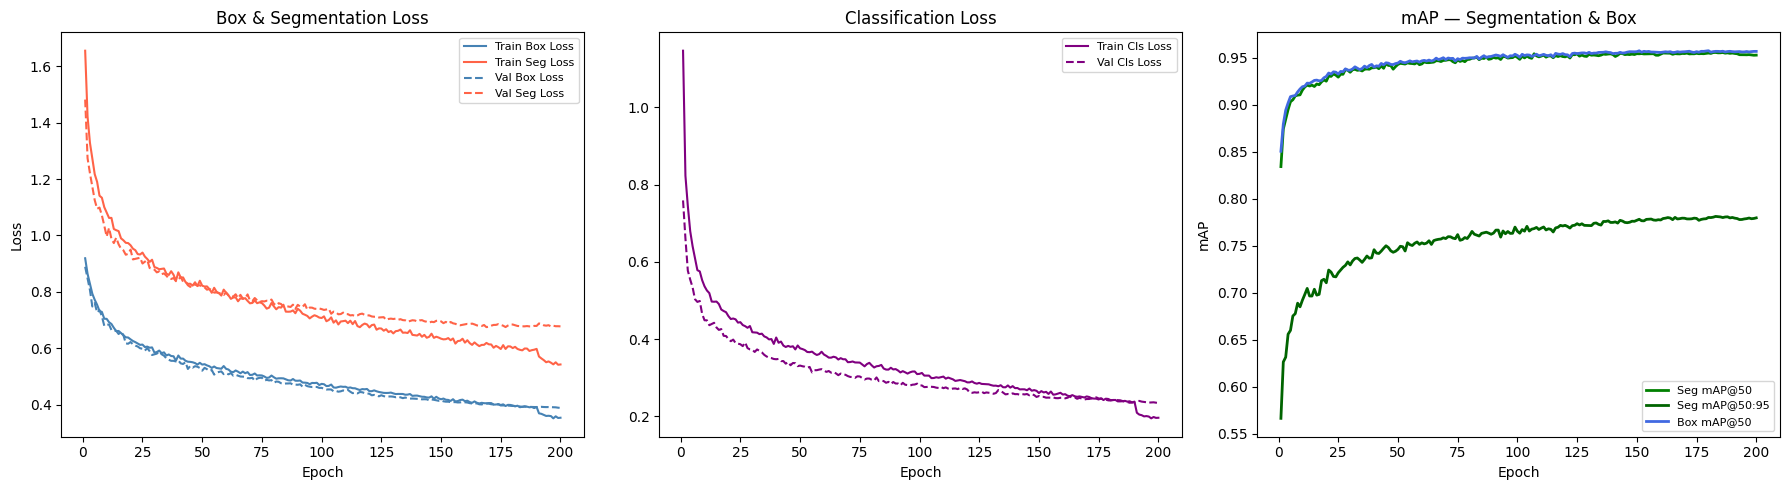

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7: Custom metric plots from results.csv
# ─────────────────────────────────────────────────────────────────────────────
if "df" in dir() and not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # — Box + Seg losses —
    ax = axes[0]
    for col, label, color in [
        ("train/box_loss",  "Train Box Loss",  "steelblue"),
        ("train/seg_loss",  "Train Seg Loss",  "tomato"),
        ("val/box_loss",    "Val Box Loss",    "steelblue"),
        ("val/seg_loss",    "Val Seg Loss",    "tomato"),
    ]:
        if col in df.columns:
            style = "--" if col.startswith("val") else "-"
            ax.plot(df["epoch"], df[col], label=label, linestyle=style, color=color)
    ax.set_title("Box & Segmentation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

    # — Classification loss —
    ax = axes[1]
    for col, label, color in [
        ("train/cls_loss", "Train Cls Loss", "purple"),
        ("val/cls_loss",   "Val Cls Loss",   "purple"),
    ]:
        if col in df.columns:
            style = "--" if col.startswith("val") else "-"
            ax.plot(df["epoch"], df[col], label=label, linestyle=style, color=color)
    ax.set_title("Classification Loss")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)

    # — mAP curves —
    ax = axes[2]
    for col, label, color in [
        ("metrics/mAP50(M)",    "Seg mAP@50",       "green"),
        ("metrics/mAP50-95(M)", "Seg mAP@50:95",    "darkgreen"),
        ("metrics/mAP50(B)",    "Box mAP@50",       "royalblue"),
    ]:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], label=label, color=color, linewidth=2)
    ax.set_title("mAP — Segmentation & Box")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("❌ Run Cell 5 (parse results) before plotting.")

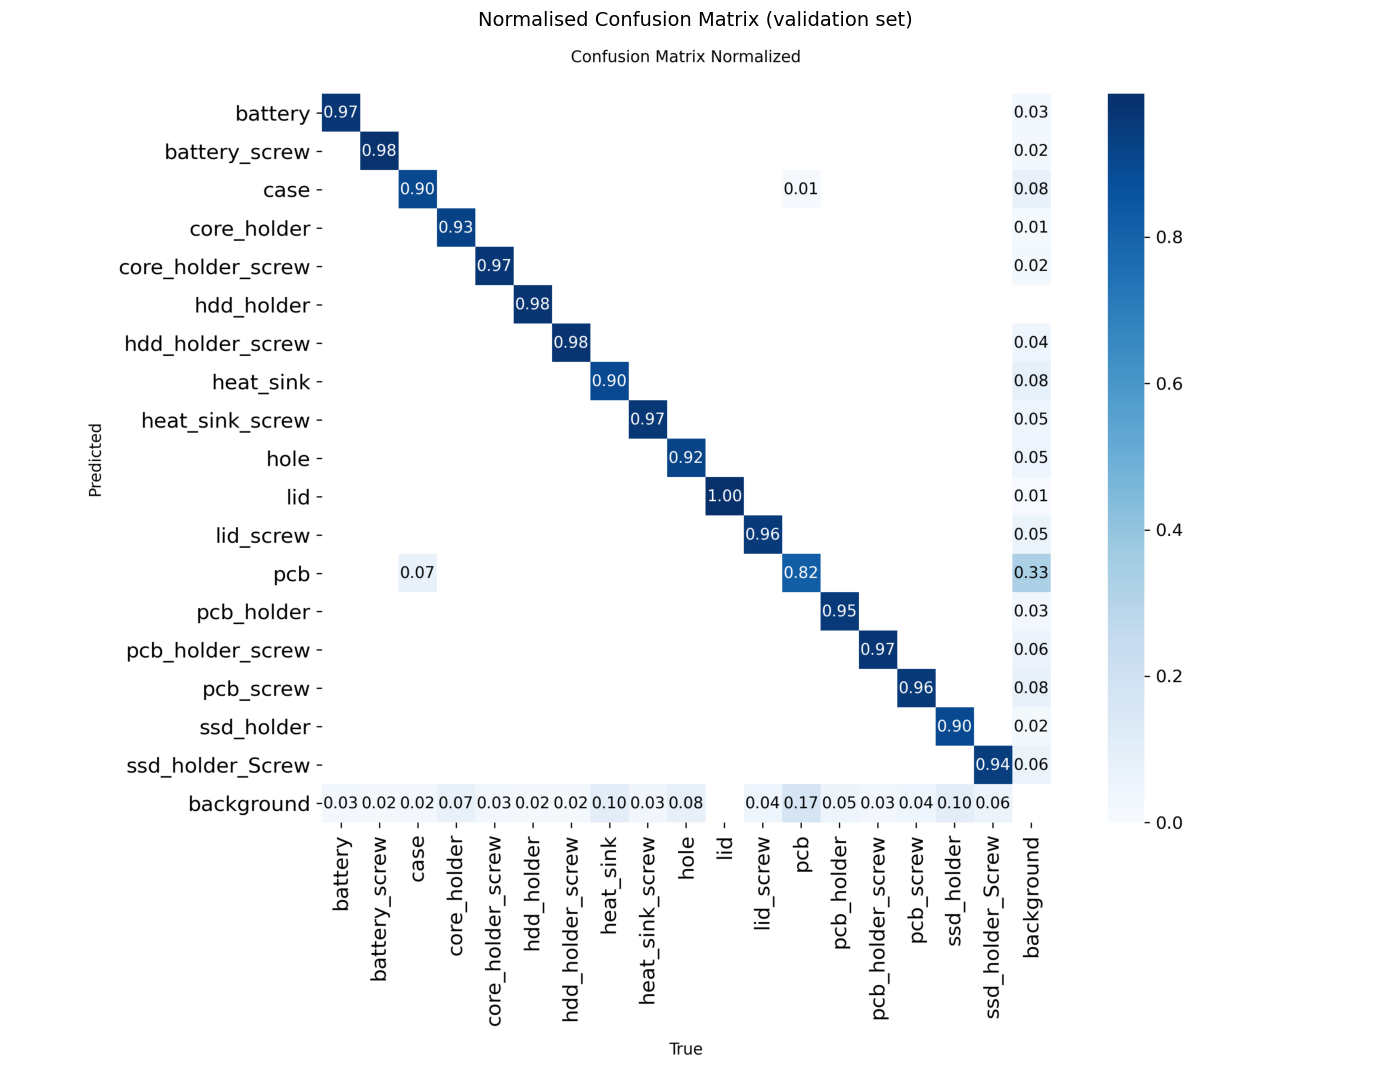

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8: Show confusion matrix (auto-generated by YOLO)
# ─────────────────────────────────────────────────────────────────────────────
cm_path = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/confusion_matrix_normalized.png"

if os.path.exists(cm_path):
    plt.figure(figsize=(14, 12))
    img = mpimg.imread(cm_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Normalised Confusion Matrix (validation set)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ {cm_path} not found — generated after val run.")

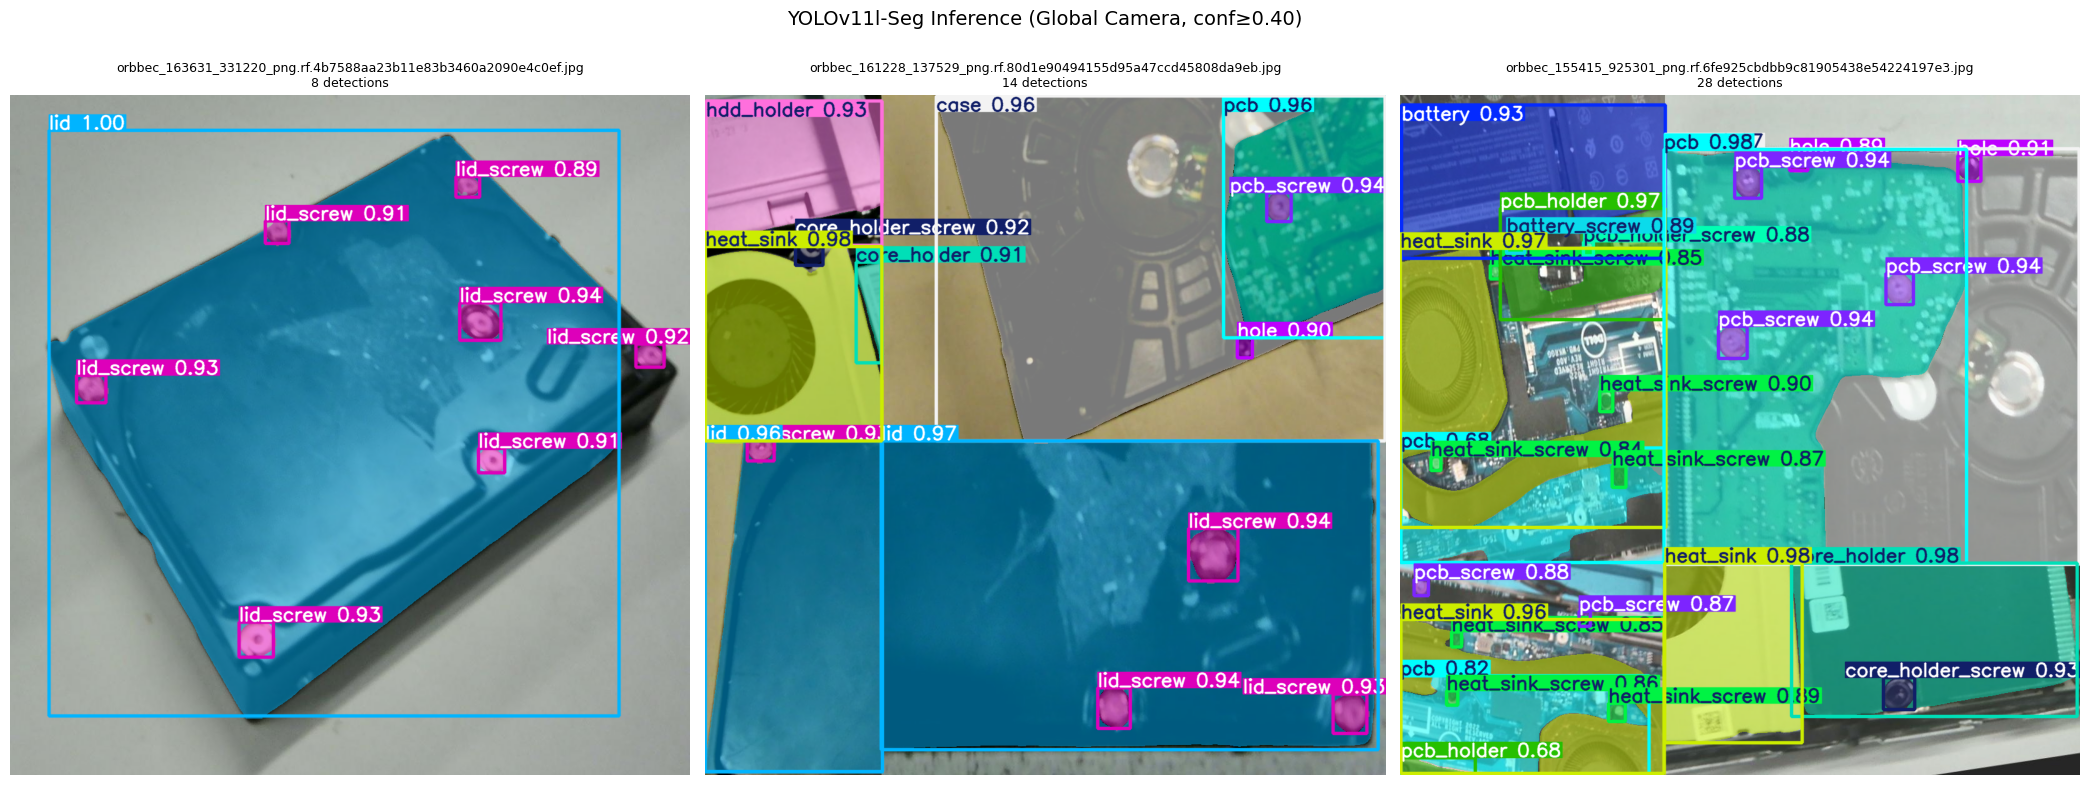

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9: Inference preview — segmentation masks on 3 test images
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

best_weights = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/weights/best.pt"
if not os.path.exists(best_weights):
    raise FileNotFoundError(f"Weights not found: {best_weights}. Run training first.")

model_inf = YOLO(best_weights)

test_imgs = sorted(glob.glob(os.path.join(OUTPUT_DIR, "test", "images", "*.jpg")))
sample    = random.sample(test_imgs, min(3, len(test_imgs)))

fig, axes = plt.subplots(1, len(sample), figsize=(7 * len(sample), 8))
if len(sample) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample):
    results = model_inf.predict(
        source    = img_path,
        conf      = 0.40,
        iou       = 0.45,
        imgsz     = 1088,
        verbose   = False,
    )
    result = results[0]
    # YOLO result.plot() renders boxes + masks
    vis = result.plot(labels=True, conf=True, masks=True, boxes=True)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    n_det = len(result.boxes) if result.boxes is not None else 0
    ax.set_title(f"{os.path.basename(img_path)}\n{n_det} detections", fontsize=9)

plt.suptitle("YOLOv11l-Seg Inference (Global Camera, conf≥0.40)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10: Evaluate on test split — full COCO metrics
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

best_weights = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/weights/best.pt"
model_eval   = YOLO(best_weights)

metrics = model_eval.val(
    data   = os.path.abspath(yaml_path),
    split  = "test",
    imgsz  = 1088,
    conf   = 0.001,    # low threshold → compute full mAP curve
    iou    = 0.6,
    verbose= True,
)

print("\n══════════════════════════════════════")
print("  TEST SET EVALUATION — YOLOv11l-Seg")
print("══════════════════════════════════════")
print(f"  Box  mAP@50      : {metrics.box.map50:.4f}")
print(f"  Box  mAP@50:95   : {metrics.box.map:.4f}")
print(f"  Mask mAP@50      : {metrics.seg.map50:.4f}")
print(f"  Mask mAP@50:95   : {metrics.seg.map:.4f}")
print("══════════════════════════════════════")

Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
YOLO11l-seg summary (fused): 204 layers, 27,598,470 parameters, 0 gradients, 131.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4107.0±723.1 MB/s, size: 114.0 KB)
val: Scanning /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/test/labels... 280 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 280/280 1.3Kit/s 0.2s<0.0s
val: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/test/images/orbbec_155337_059896_png.rf.934d6f55bf599075fc5e23819bca47f6.jpg: 1 duplicate labels removed
val: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/dataset_yolo11_seg_1080/test/images/orbbec_155415_925301_png.rf.a2e1cf23e566912a0c5e31c0028e8f39.jpg: 1 duplicate labe

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.20 GiB. GPU 0 has a total capacity of 7.62 GiB of which 873.06 MiB is free. Including non-PyTorch memory, this process has 6.72 GiB memory in use. Of the allocated memory 4.29 GiB is allocated by PyTorch, and 2.21 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11: Export best model to ONNX for deployment
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

best_weights = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/weights/best.pt"
model_export = YOLO(best_weights)

export_path = model_export.export(
    format  = "onnx",
    imgsz   = 1088,
    dynamic = True,     # dynamic input axes
    opset   = 17,
    simplify= True,
)

print(f"\n✅ ONNX model exported to: {export_path}")
print("   Copy best.pt to global_model/ for use by GlobalVisionNode.")

Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CPU (Intel Core i7-14700HX)
YOLO11l-seg summary (fused): 204 layers, 27,598,470 parameters, 0 gradients, 131.9 GFLOPs

PyTorch: starting from '/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/weights/best.pt' with input shape (1, 3, 1088, 1088) BCHW and output shape(s) ((1, 54, 24276), (1, 32, 272, 272)) (53.4 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.3s, saved as '/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/weights/best.onnx' (106.3 MB)

Export complete (5.2s)
Results saved to /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 1 (Segmentation)/rfdetr/runs/yolo11l_seg_1088/weights/best.onnx
Predict:         yolo predict task=segment model=/home/adip/workspace